# Day 21: In-Class Assignment

___


### <p style="text-align: right;"> &#9989;&nbsp; **Put your name here** </p>
#### <p style="text-align: right;"> &#9989;&nbsp; Put your group member names here</p>

## Grow switchgrass anywhere with this neat hack

<img src="https://images.ctfassets.net/zma7thmmcinb/4EDBQeX2oHVXGbOUgJ9X5m/50d98036a7e834bf495c9c596b8074fe/179-switchgrass-Cloud-Nine.jpg" style="display:block; margin-left: auto; margin-right: auto; width: 65%" alt="Three switchgrass shrubs">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://www.gardengatemagazine.com/articles/how-to/support-pollinators-wildlife/did-you-know-switch-grass-is-a-butterfly-host-plant/" target="_blank">Garden Gate magazine</a></p>

### Learning goals of today's assignment

* Use `stats` to compute Welch's t-tests and realize they are a much better alternative than Student's t-tests
* Notice that different comparison tests can result in very different conclusions
* Realize that it is possible to conclude that a difference is both significant and not significant

## Assignment instructions

Work with your group to complete this assignment. Instructions for submitting this assignment are at the end of the Notebook. The assignment is due at the end of class.

___

## Importing the modules that we will need

Before we start anything, it is good practice to have all our imports as the first Python cell

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from sklearn import metrics

---

## 1. Switchgrass, revisited

In the pre-class Notebook we re-explored the switchgrass yield data from [Ricketts et al (2023)](https://doi.org/10.1111/gcbb.13046). We will keep exploring the question

> When growing switchgrass **in Missouri**, do different switchgrass cultivars yield different biomasses?

- We first load and wrangle the `'HARVEST.tsv'` file

In [2]:
# Repeating pre-class

data = pd.read_csv('HARVEST.tsv', sep='\t')
data.head()

,YEAR,SITE,SITE_YR,PLOT_GL,Block,PLOT,GENO,ECOTYPE,TIME_SET,ADJ_FULL_JD,...,DLY240_TMIN_Avg,DLY240_Pen_PET,DLY270_PRCP_Totals,DLY270_TMAX_Avg,DLY270_TMIN_Avg,DLY270_Pen_PET,DLY365_PRCP_Totals,DLY365_TMAX_Avg,DLY365_TMIN_Avg,DLY365_Pen_PET
0,Y2017,IL,IL_17,IL.1A,IL.1,1A,Liberty,Hybrids,Harvest,IL117329,...,9.556829,119.284155,1025.652,19.863785,8.355337,114.936714,NaN,NaN,NaN,NaN
1,Y2017,IL,IL_17,IL.1B,IL.1,1B,Carthage,Hybrids,Harvest,IL117329,...,9.556829,119.284155,1025.652,19.863785,8.355337,114.936714,NaN,NaN,NaN,NaN
2,Y2017,IL,IL_17,IL.1C,IL.1,1C,Kanlow,Lowlands,Harvest,IL117329,...,9.556829,119.284155,1025.652,19.863785,8.355337,114.936714,NaN,NaN,NaN,NaN
3,Y2017,IL,IL_17,IL.1D,IL.1,1D,Blackwell,Uplands,Harvest,IL117329,...,9.556829,119.284155,1025.652,19.863785,8.355337,114.936714,NaN,NaN,NaN,NaN
4,Y2017,IL,IL_17,IL.1E,IL.1,1E,Alamo,Lowlands,Harvest,IL117329,...,9.556829,119.284155,1025.652,19.863785,8.355337,114.936714,NaN,NaN,NaN,NaN


- Get only data corresponding to Missouri
- **We will use only this sub-dataset for the rest of the assignment**.

In [3]:
site = 'MO'
df = data[ data['SITE'] == site ]
df.head()

,YEAR,SITE,SITE_YR,PLOT_GL,Block,PLOT,GENO,ECOTYPE,TIME_SET,ADJ_FULL_JD,...,DLY240_TMIN_Avg,DLY240_Pen_PET,DLY270_PRCP_Totals,DLY270_TMAX_Avg,DLY270_TMIN_Avg,DLY270_Pen_PET,DLY365_PRCP_Totals,DLY365_TMAX_Avg,DLY365_TMIN_Avg,DLY365_Pen_PET
30,Y2017,MO,MO_17,MO.1A,MO.1,1A,Alamo,Lowlands,Harvest,MO117303,...,12.274583,156.304325,799.33,23.03,10.919259,151.770224,909.312,18.947893,7.316033,131.010255
31,Y2017,MO,MO_17,MO.1B,MO.1,1B,Liberty,Hybrids,Harvest,MO117303,...,12.274583,156.304325,799.33,23.03,10.919259,151.770224,909.312,18.947893,7.316033,131.010255
32,Y2017,MO,MO_17,MO.1C,MO.1,1C,Kanlow,Lowlands,Harvest,MO117303,...,12.274583,156.304325,799.33,23.03,10.919259,151.770224,909.312,18.947893,7.316033,131.010255
33,Y2017,MO,MO_17,MO.1D,MO.1,1D,Blackwell,Uplands,Harvest,MO117303,...,12.274583,156.304325,799.33,23.03,10.919259,151.770224,909.312,18.947893,7.316033,131.010255
34,Y2017,MO,MO_17,MO.1E,MO.1,1E,Carthage,Hybrids,Harvest,MO117303,...,12.274583,156.304325,799.33,23.03,10.919259,151.770224,909.312,18.947893,7.316033,131.010255


---

## 2. Q-Q plots and normality plots

Before making any comparisons, we should check whether the yield data are normal-ish or not. We then do some Q-Q plots to check if the quantiles of our data follow the same quantiles of a theoretical normal distribution.

### 2.1 Start with one cultivar: Carthage

Before doing a big plot with all sorts of Q-Qs at once, let's make sure how things work for a single cultivar. We can then just put it in a loop and do the rest.

&#9989;&nbsp; **Task 1**

- Make a NumPy `quantiles` array of $N = 10$ values between $0.1$ and $1 - 0.1 = 0.9$. We choose $N = 15$ because it is comparable to our switchgrass sample size ($n = 20$).
- Get a Series with only the Carthage yield data and compute its quantiles (the ones from `quantiles`).

*Hint*: [the `np.quantile` function](https://numpy.org/doc/stable/reference/generated/numpy.quantile.html) says `q:  array_like of float`. This means that you can have `q = quantiles` and the function will produce all those quantiles at once.

In [4]:
# Your code

&#9989;&nbsp; **Task 2**

- Get the mean and standard deviation of Carthage yield
- With [the `stats.norm.ppf` function](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html), compute the `quantiles` of a normal with mean and SD of Carthage (`loc` and `scale`, respectively)

*Hint*: Just like with `np.quantiles`, the quantiles for `.ppf` can be passed as an array.

In [5]:
# Your code

&#9989;&nbsp; **Task 3**

- Now do a Q-Q scatterplot: theoretical quantiles (T2) vs data quantiles (T1)
- With [`axline` draw](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.axline.html) an identity line ($x = y$).
    - The identity line has points of the form `(x, x)`: for example,  `(data_quantile[0], data_quantile[0])`.
    - The identity line has slope `1`

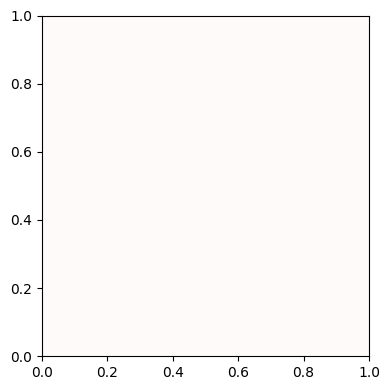

In [6]:
# Finish the plot

fig, ax = plt.subplots(1,1, figsize=(4,4), sharex=False, sharey=True)
ax = np.atleast_1d(ax)
ax[0].set_facecolor('snow')

# Q-Q plot

fig.tight_layout()

&#9989;&nbsp; **Question 4**

- Based on the Q-Q plot alone, do you think the Carthage data is normally distributed?

**Note**: Your points will *almost never* fall in a perfect diagonal line, even when perfectly normal. But they are reasonably close to the identity line. Take a look at [section 4.4.1 here](https://sscc.wisc.edu/sscc/pubs/RegDiag-R/normality.html#normal) which shows various Q-Q plots drawn from actual normal distributions.

<font size=+3>&#9998;</font> *Put your answer*


### 2.2 Put everything on a loop

&#9989;&nbsp; **Task 5**

- Finish the loop, now repeating the plot from T6 but for all six cultivars at once
- Make sure you have an identity line in each subplot
- Add a title to each subplot so you know which cultivar is which plot

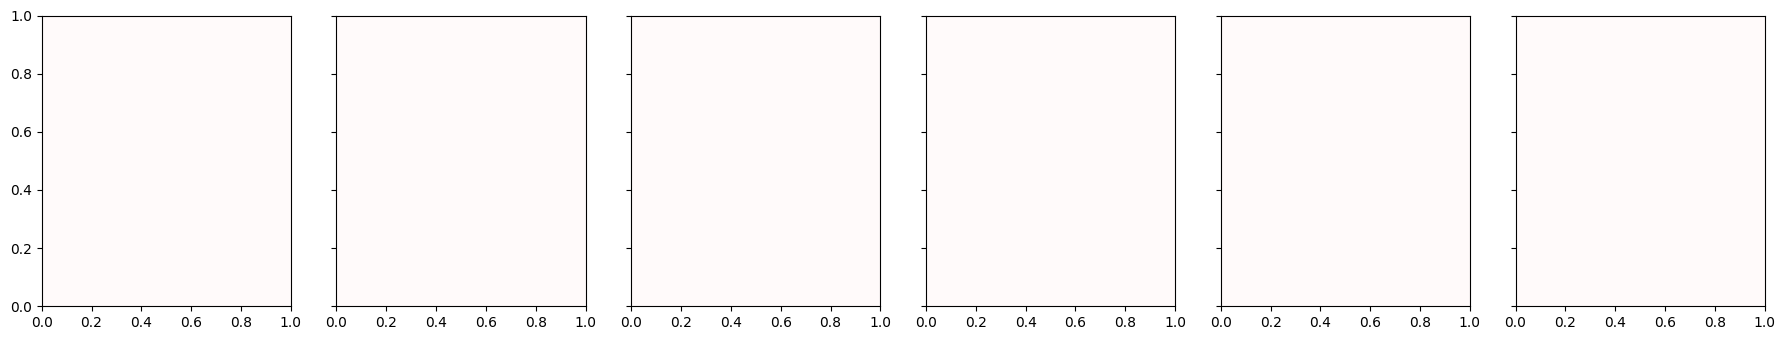

In [7]:
genos = ['Alamo', 'Kanlow', 'Carthage', 'Liberty', 'CIR', 'Blackwell']

fig, ax = plt.subplots(1, len(genos), figsize=(3*len(genos), 3.5), sharex=False, sharey=True)
for i in range(len(genos)):

    ax[i].set_facecolor('snow')
    # Q-Q plots

fig.tight_layout()

&#9989;&nbsp; **Question 6**

- Based on the Q-Q plots alone, do you think the yield data in general are normal-ish distributed?
- Put another way: do the points deviate significantly from the identity line? If you [keep scrolling here](https://sscc.wisc.edu/sscc/pubs/RegDiag-R/normality.html#normal), you'll see Q-Q plots that are NOT normal.

<font size=+3>&#9998;</font> *Put your answer*


&#9989;&nbsp; **Question 7**

- Do you think it makes sense to compare yield data with Welch's test?

<font size=+3>&#9998;</font> *Put your answer*


---

## 3. Two-sample tests and p-value adjustment

The data seems reasonably normal-ish to go with Welch's.

&#9989;&nbsp; **Question 8**

Say you perform a Welch's test between Carthage and Alamo.

- In switchgrass yield terms, what is the null hypothesis being tested by Welch's in such case?

<font size=+3>&#9998;</font> *Put your answer*


&#9989;&nbsp; **Task 9**

- With data from $n = 4\;\text{years}\times 5\;\text{repetitions} = 20$, check which cultivars yield the same biomass when grown in Missouri.
- Use Welch's t-tests to compare every cultivar against each other.
- Make sure you don't compare a cultivar against itself.
- Store your p-values as a Series, where the indices keep track of what two cultivars you're comparing.

In [8]:
# Your code


&#9989;&nbsp; **Task 10**

Just like last time, before calling it a day, we must adjust these p-values for false positives.

- Perform a Benjamini-Hochberg adjustment to the p-values from T9
- Put the results in a Series so you still can track what p-value goes with which cultivars

In [9]:
# Your code

&#9989;&nbsp; **Question 11**

Make sure you discuss this with your group:

- Based on your Welch's adjusted p-values, are the yields of Carthage and Blackwell different?
- But how do your conclusions compare when you did Mann-Whitney for the pre-class (if you did not do the pre-class, just run all the cells and check the output of Part 3)?
- Which is the right call?

<font size=+3>&#9998;</font> *Put your answer*


---

## 4. When in doubt, visualize (actually, always visualize)

Below is a jitterplot with the actual yield data for all the years and all the cultivars in Missouri. We also draw the 95% confidence intervals.

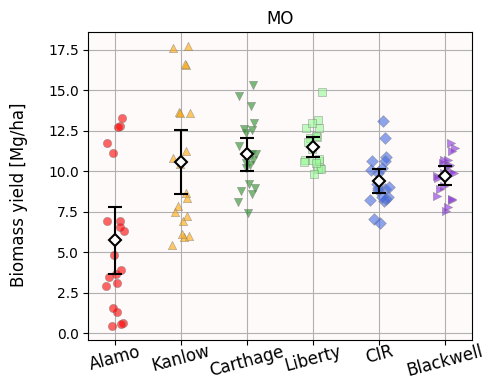

In [10]:
fs = 12
rng = np.random.default_rng(42)
nudge = rng.uniform(-0.15,.15, 1000)

colors = ['r', 'orange', 'forestgreen', 'palegreen', 'royalblue', 'blueviolet']
markers = ['o','^','v','s','D','>']

# The actual plot
fig, ax = plt.subplots(1,1,figsize=(5,4), sharex=True, sharey=True)
ax = np.atleast_1d(ax)
i = 0
ax[i].set_title(site, fontsize=fs)
ax[i].set_facecolor('snow')
ax[i].grid(zorder= 1)
ax[i].set_xticks(range(len(genos)), genos, fontsize=fs, rotation=15, va='center_baseline')

for j in range(len(genos)):
    yi = df.loc[df['GENO'] == genos[j], 'BIOMASS_AVG_Mg_ha']
    ci = stats.t.ppf(0.975, len(yi)-1)*yi.sem()
    
    ax[i].scatter(j + nudge[:len(yi)], yi, c=colors[j], marker=markers[j], alpha=0.6, ec='gray', lw=0.5, zorder=3)
    ax[i].errorbar(j, yi.mean(), yerr=ci, color='k', mew=1.5, elinewidth=1.5, capsize=5, mfc='w', marker='D', zorder=3)

fig.supylabel('Biomass yield [Mg/ha]', fontsize=fs)
fig.tight_layout();

&#9989;&nbsp; **Question 11**

- Look at the p-values between Alamo and Liberty: do they match your visuals?
- What about Kanlow vs Carthage?

Remember your rule of thumb regarding significant p-values and overlaps between confidence intervals.

<font size=+3>&#9998;</font> *Put your answer*


&#9989;&nbsp; **Question 12**

- What about Carthage vs Blackwell? Does the visualization change your answer from Q10?

<font size=+3>&#9998;</font> *Put your answer*


&#9989;&nbsp; **Question 13**

Take a step back: Are we going to ignore all our domain knowledge in favor of a single p-value?

- What else could you do to break the impasse to decide if Carthage and Blackwell are truly different or not?

<font size=+3>&#9998;</font> *Put your answer*


---

## 5. To hack or not to hack

As you see, without the need of any cherry-picking&mdash;or any other irresponsible practices&mdash;we can construct a story in such a way that the yield from Carthage and Blackwell is statistically similar. We can also construct a story where these yields are statistically different. 

We can p-hack! We can just report the test that reflects what we want!

If your research or graduation depends on proving the superiority of Carthage over Blackwell&mdash;or the other way around&mdash;you can see that our personal bias can influence which story we choose.


### 5.1 Remember that 0.05 is arbitrary

When it comes to corrected p-value of Blackwell vs Carthage, we are facing the choice of:

- Mann-Whitney's U-test has a p-value of 0.08, which we deem not significant &rarr; both cultivars have similar yields
- Welch's t-test has a p-value of 0.04, which we deem significant &rarr; both cultivars have different yields

But this *deeming as significant* affair is arbitrarily based on $0.05$. 

- We can say from the get-go: we will only consider p-values below $0.01$ as significant. That way, Blackwell vs Carthage is non-significant either way.
- Alternatively, we can say that Blackwell vs Carthage is "borderline significant", with a p-value of 0.08 and we let the rest of scientific readers decide if 0.08 is small enough or not.

**Either way, you should provide a data visualization to let readers decide by themselves.**

&#9989;&nbsp; **Question 14**

Changing the significance level from 0.05 level is not a silver bullet. 

- Can you think of ways we can also hack by moving the significance threshold?

<font size=+3>&#9998;</font> *Put your answer*


---

## Congratulations, you're done!

Submit this assignment by uploading it to the course Canvas web page.  Go to the "In-class assignments" folder, find the appropriate submission link, and upload it there.

See you next class!

&#169; Copyright 2026,  Division of Plant Science & Technology&mdash;University of Missouri